注意环境：tensorflow1.0，禁用gpu  
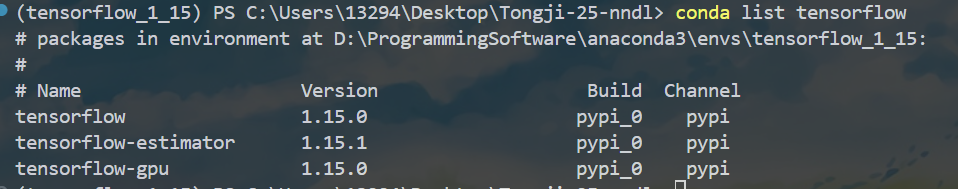

In [1]:
import tensorflow as tf
from tensorflow.examples.tutorials.mnist import input_data
# from torchvision.datasets import MNIST
mnist = input_data.read_data_sets('mnist', one_hot=True)
# mnist = MNIST(root='./mnist', train=True, download=True)

from tensorflow.python.framework import ops
ops.reset_default_graph()
# 禁用 GPU
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

learning_rate = 1e-4
keep_prob_rate = 0.7 # 
max_epoch = 2000
def compute_accuracy(v_xs, v_ys):
    global prediction
    y_pre = sess.run(prediction, feed_dict={xs: v_xs, keep_prob: 1})
    correct_prediction = tf.equal(tf.argmax(y_pre,1), tf.argmax(v_ys,1))
    accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
    result = sess.run(accuracy, feed_dict={xs: v_xs, ys: v_ys, keep_prob: 1})
    return result

def weight_variable(shape):
    initial = tf.truncated_normal(shape, stddev=0.1)
    return tf.Variable(initial)

def bias_variable(shape):
    initial = tf.constant(0.1, shape=shape)
    return tf.Variable(initial)

def conv2d(x, W):
    # 每一维度  滑动步长全部是 1， padding 方式 选择 same
    # 提示 使用函数  tf.nn.conv2d
    return tf.nn.conv2d(x, W, strides=[1, 1, 1, 1], padding='SAME')

def max_pool_2x2(x):
    # 滑动步长 是 2步; 池化窗口的尺度 高和宽度都是2; padding 方式 请选择 same
    # 提示 使用函数  tf.nn.max_pool
    return tf.nn.max_pool(x, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME') 

# define placeholder for inputs to network
xs = tf.placeholder(tf.float32, [None, 784])/255.
ys = tf.placeholder(tf.float32, [None, 10])
keep_prob = tf.placeholder(tf.float32)
# xs = tf.keras.Input(shape=(784,), dtype=tf.float32)
# ys = tf.keras.Input(shape=(10,), dtype=tf.float32)
# keep_prob = tf.keras.Input(shape=(), dtype=tf.float32)
x_image = tf.reshape(xs, [-1, 28, 28, 1])

#  卷积层 1
## conv1 layer ## TODO
W_conv1 = weight_variable([7, 7, 1, 32])  # patch 7x7, in size 1, out size 32
b_conv1 = bias_variable([32])
h_conv1 = conv2d(x_image, W_conv1)  # 卷积操作
h_conv1 = tf.nn.relu(h_conv1 + b_conv1)  # ReLU激活函数
h_pool1 = max_pool_2x2(h_conv1)  # 池化操作

# 卷积层 2 TODO
W_conv2 = weight_variable([5, 5, 32, 64])  # patch 5x5, in size 32, out size 64
b_conv2 = bias_variable([64])
h_conv2 = conv2d(h_pool1, W_conv2)  # 卷积操作
h_conv2 = tf.nn.relu(h_conv2 + b_conv2)  # ReLU激活函数
h_pool2 = max_pool_2x2(h_conv2)  # 池化操作

#  全连接层 1
## fc1 layer ##
W_fc1 = weight_variable([7*7*64, 1024])
b_fc1 = bias_variable([1024])

h_pool2_flat = tf.reshape(h_pool2, [-1, 7*7*64])
h_fc1 = tf.nn.relu(tf.matmul(h_pool2_flat, W_fc1) + b_fc1)
h_fc1_drop = tf.nn.dropout(h_fc1, keep_prob)

# 全连接层 2
## fc2 layer ##
W_fc2 = weight_variable([1024, 10])
b_fc2 = bias_variable([10])
prediction = tf.nn.softmax(tf.matmul(h_fc1_drop, W_fc2) + b_fc2)


# 交叉熵函数
cross_entropy = tf.reduce_mean(-tf.reduce_sum(ys * tf.log(prediction),
                                              reduction_indices=[1]))
train_step = tf.train.AdamOptimizer(learning_rate).minimize(cross_entropy)

with tf.Session() as sess:
    init = tf.global_variables_initializer()
    sess.run(init)
    
    for i in range(max_epoch):
        batch_xs, batch_ys = mnist.train.next_batch(8) # 100改成了8
        sess.run(train_step, feed_dict={xs: batch_xs, ys: batch_ys, keep_prob:keep_prob_rate})
        if i % 100 == 0:
            print(compute_accuracy(
                mnist.test.images[:1000], mnist.test.labels[:1000]))


Instructions for updating:
Please use alternatives such as official/mnist/dataset.py from tensorflow/models.
Instructions for updating:
Please write your own downloading logic.
Instructions for updating:
Please use tf.data to implement this functionality.
Extracting mnist\train-images-idx3-ubyte.gz
Instructions for updating:
Please use tf.data to implement this functionality.
Extracting mnist\train-labels-idx1-ubyte.gz
Instructions for updating:
Please use tf.one_hot on tensors.
Extracting mnist\t10k-images-idx3-ubyte.gz
Extracting mnist\t10k-labels-idx1-ubyte.gz
Instructions for updating:
Please use alternatives such as official/mnist/dataset.py from tensorflow/models.
Num GPUs Available:  0
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
0.062
0.761
0.799
0.845
0.877
0.903
0.893
0.899
0.909
0.916
0.921
0.93
0.923
0.933
0.942
0.939
0.939
0.95
0.955
0.963
